# Day 1 | Notebook 2: Algorithms & FAISS Deep Dive
**Author: Sattaya Singkul**

Welcome to the second part of the Vector Database fundamentals course! 

Now we understand the math, but writing standard `for` loops against millions of High-Dimensional vectors will crash a regular server. We need **Indexing Algorithms**.

We will use **Facebook AI Similarity Search (FAISS)**, the industry-standard C++ engine for learning these algorithms.

### Core Objectives:
1. **Flat Index (KNN)**: Prove linear scaling bottleneck.
2. **IVF**: Use FAISS to map Centroids.
3. **PQ**: Use FAISS to compress bytes and prove RAM savings.
4. **HNSW**: Draw the multi-graph routing system.
5. **Mega Benchmark**: Clock all 4 FAISS algorithms across 50,000 vectors!


In [1]:
!pip install numpy matplotlib seaborn tqdm faiss-cpu networkx scipy

## Step 1: Flat / K-Nearest Neighbors (KNN) - "The Brute Force"
**How it works:** Compares against *every single vector*. Let's prove why $O(N)$ scanning scales poorly. We will use `faiss.IndexFlatL2`.


Running FAISS Brute Force (KNN Flat) benchmarking...
FAISS Searched 10,000 vectors in 0.0003 seconds
FAISS Searched 50,000 vectors in 0.0009 seconds
FAISS Searched 100,000 vectors in 0.0016 seconds
FAISS Searched 200,000 vectors in 0.0034 seconds


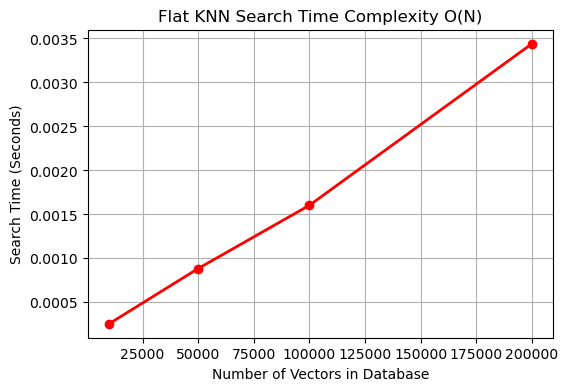

This is why Flat search is strictly for 'small' datasets (< 50,000)! It simply takes too long.


In [2]:
import time
import faiss
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DIMENSIONS = 128
DB_SIZES = [10_000, 50_000, 100_000, 200_000]
query = np.random.rand(1, DIMENSIONS).astype(np.float32)

times = []
print("Running FAISS Brute Force (KNN Flat) benchmarking...")
for size in DB_SIZES:
    db = np.random.rand(size, DIMENSIONS).astype(np.float32)
    
    # 1. Initialize FAISS Flat Index
    index = faiss.IndexFlatL2(DIMENSIONS)
    index.add(db)
    
    # 2. Benchmark Search
    start = time.time()
    D, I = index.search(query, 5) # Find top 5
    duration = time.time() - start
    
    times.append(duration)
    print(f"FAISS Searched {size:,} vectors in {duration:.4f} seconds")

plt.figure(figsize=(6, 4))
plt.plot(DB_SIZES, times, marker='o', color='red', linewidth=2)
plt.title("Flat KNN Search Time Complexity O(N)")
plt.xlabel("Number of Vectors in Database")
plt.ylabel("Search Time (Seconds)")
plt.grid(True)
plt.show()

print("This is why Flat search is strictly for 'small' datasets (< 50,000)! It simply takes too long.")


## Step 2: Inverted File Index (IVF) - "Clustering"
**How it works:** We cluster vectors into "buckets" (Centroids) using K-Means. At search time, we only calculate distance to the centroids, pick the closest, and only scan those specific vectors. Time complexity drops to $O(N/K)$!

In FAISS, this requires **Training** the centroids first.


In [3]:
d = 128
nb = 100_000 # 100k DB size
db = np.random.rand(nb, d).astype(np.float32)
q = np.random.rand(1, d).astype(np.float32)

nlist = 100 # How many centroids (buckets) we want
quantizer = faiss.IndexFlatL2(d)  # The algorithm used to assign vectors to buckets
index_ivf = faiss.IndexIVFFlat(quantizer, d, nlist)

print("Training FAISS IVF Index... (Learning where to put the 100 buckets)")
assert not index_ivf.is_trained
index_ivf.train(db)
assert index_ivf.is_trained

print("Adding 100k vectors to the index buckets...")
index_ivf.add(db)

# We can adjust nprobe. Finding the balance between Speed vs Accuracy (Recall).
# nprobe = 1 means search ONLY the 1 absolute closest bucket (out of 100). Fast, but risky!
index_ivf.nprobe = 1 
start = time.time()
D, I = index_ivf.search(q, 5)
print(f"Scanned using nprobe=1 in {time.time()-start:.4f} seconds!")

# nprobe = 10 means search the 10 closest buckets. Slower, but higher chance to find the true neighbor.
index_ivf.nprobe = 10
start = time.time()
D, I = index_ivf.search(q, 5)
print(f"Scanned using nprobe=10 in {time.time()-start:.4f} seconds!")


Training FAISS IVF Index... (Learning where to put the 100 buckets)
Adding 100k vectors to the index buckets...
Scanned using nprobe=1 in 0.0002 seconds!
Scanned using nprobe=10 in 0.0003 seconds!


## Step 3: Product Quantization (PQ) - "Compression"
**How it works:** PQ splits high-dimensional floats into "chunks", replacing the chunk with an 8-bit ID mapping to a sub-centroid. It drastically reduces Memory (RAM).

Let's use `faiss.IndexPQ` to build an index and check the explicit byte size in memory to prove how deeply it compresses!


In [5]:
import sys
import os

d = 128
nb = 100_000 # 100k DB size

# Base Flat Index Memory Size
index_flat = faiss.IndexFlatL2(d)
index_flat.add(db)

# Base PQ Index (Compress 128 floats into 8 chunks of 1 byte)
m = 8 # Number of chunks
index_pq = faiss.IndexPQ(d, m, 8) 
index_pq.train(db)
index_pq.add(db)

# Let's save them to disk or ram to check raw byte size
faiss.write_index(index_flat, "flat.index")
faiss.write_index(index_pq, "pq.index")

size_flat = os.path.getsize("flat.index")
size_pq = os.path.getsize("pq.index")

print(f"Flat Index Disk/RAM Size: {size_flat / 1024 / 1024:.2f} MB")
print(f"PQ Compressed Index Size: {size_pq / 1024 / 1024:.2f} MB")
print(f"Total Memory Reduction: {(1 - size_pq/size_flat)*100:.1f}% !!")


Flat Index Disk/RAM Size: 48.83 MB
PQ Compressed Index Size: 0.89 MB
Total Memory Reduction: 98.2% !!


## Step 4: Hierarchical Navigable Small World (HNSW) - "The Graph"
**HNSW** is the industry standard (Redis, Pinecone). It builds a multi-layered skip-graph. Top layers have few sparse nodes for "fast jumping", while bottom layers are densely connected. 
Let's visually draw what an HNSW graph looks like using `networkx`!


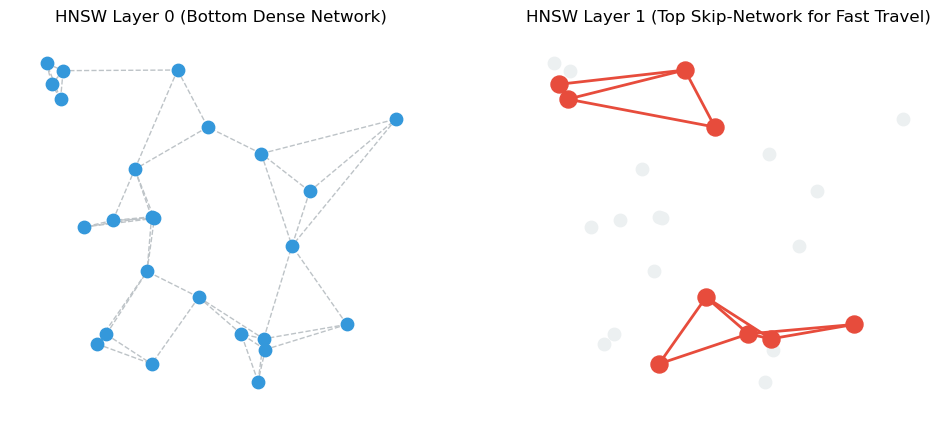

In [6]:
import networkx as nx
from scipy.spatial.distance import cdist

# Generate random points
np.random.seed(42)
points = np.random.rand(25, 2)

# Create two networks: Layer 0 (dense bottom), Layer 1 (sparse skip-graph)
G0 = nx.Graph()
G1 = nx.Graph()

for i, p in enumerate(points):
    G0.add_node(i, pos=p)
    if i % 3 == 0:  # Only ~30% of nodes make it to Layer 1
        G1.add_node(i, pos=p)

# Connect nearest neighbors in G0 (Dense)
dist = cdist(points, points)
for i in range(len(points)):
    nearest = np.argsort(dist[i])[1:4] # connect 3 closest
    for n in nearest: G0.add_edge(i, n)

# Connect in G1 (Sparse)
l1_nodes = list(G1.nodes())
l1_points = points[l1_nodes]
dist_l1 = cdist(l1_points, l1_points)
for idx, i in enumerate(l1_nodes):
    nearest_idx = np.argsort(dist_l1[idx])[1:3] # connect 2 skip nodes
    for n_idx in nearest_idx: G1.add_edge(i, l1_nodes[n_idx])

# Plotting the Graph Layers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
pos = {i: points[i] for i in range(len(points))}

ax1.set_title("HNSW Layer 0 (Bottom Dense Network)")
nx.draw(G0, pos, ax=ax1, node_size=80, node_color='#3498db', edge_color='#bdc3c7', style='dashed')

ax2.set_title("HNSW Layer 1 (Top Skip-Network for Fast Travel)")
nx.draw(G0, pos, ax=ax2, node_size=80, node_color='#ecf0f1', edge_color='none') 
nx.draw(G1, pos, ax=ax2, node_size=150, node_color='#e74c3c', edge_color='#e74c3c', width=2)
plt.show()


## Step 5: Live Code BENCHMARK - Speed vs Recall!
Let's benchmark all 4 FAISS algorithms over 50,000 vectors dynamically.


/tmp/ipykernel_676/2606875342.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=times, ax=ax1, palette='rocket')
/tmp/ipykernel_676/2606875342.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=recalls, ax=ax2, palette='mako')


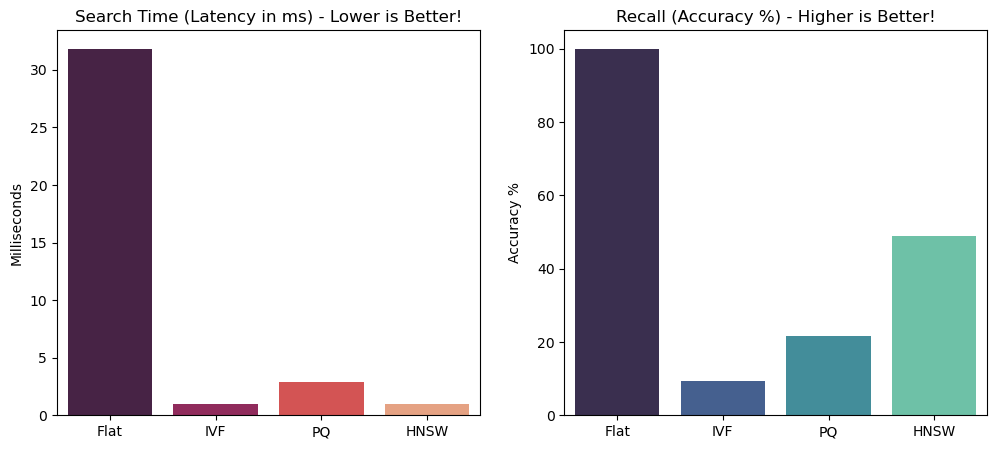


--- RESULTS ANALYSIS ---
[Flat] Latency: 31.85 ms | Recall: 100.0%
[IVF] Latency: 1.01 ms | Recall: 9.4%
[PQ] Latency: 2.91 ms | Recall: 21.6%
[HNSW] Latency: 0.94 ms | Recall: 49.0%


In [7]:
d = 64        # dimensions
nb = 50_000   # database size
nq = 100      # query size

np.random.seed(123)
xb = np.random.random((nb, d)).astype('float32') # Database
xq = np.random.random((nq, d)).astype('float32') # Queries

def calculate_recall(true_I, pred_I):
    recalls = []
    for i in range(len(true_I)):
        hits = np.intersect1d(true_I[i], pred_I[i])
        recalls.append(len(hits) / len(true_I[i]))
    return np.mean(recalls) * 100

results = {}

# 1. FLAT (Exact KNN)
index_flat = faiss.IndexFlatL2(d)
index_flat.add(xb)
start = time.time()
D_flat, I_flat = index_flat.search(xq, 5) # Find top 5
res_flat = {'time': (time.time() - start) * 1000, 'recall': 100.0}
results['Flat'] = res_flat

# 2. IVF
nlist = 100
index_ivf = faiss.IndexIVFFlat(faiss.IndexFlatL2(d), d, nlist)
index_ivf.train(xb)
index_ivf.add(xb)
index_ivf.nprobe = 1 # Search only 1 bucket for high speed
start = time.time()
D_ivf, I_ivf = index_ivf.search(xq, 5)
results['IVF'] = {'time': (time.time() - start) * 1000, 'recall': calculate_recall(I_flat, I_ivf)}

# 3. PQ (Product Quantization)
m = 8 # bytes per vector
index_pq = faiss.IndexPQ(d, m, 8)
index_pq.train(xb)
index_pq.add(xb)
start = time.time()
D_pq, I_pq = index_pq.search(xq, 5)
results['PQ'] = {'time': (time.time() - start) * 1000, 'recall': calculate_recall(I_flat, I_pq)}

# 4. HNSW
index_hnsw = faiss.IndexHNSWFlat(d, 32)
index_hnsw.add(xb)
start = time.time()
D_hnsw, I_hnsw = index_hnsw.search(xq, 5)
results['HNSW'] = {'time': (time.time() - start) * 1000, 'recall': calculate_recall(I_flat, I_hnsw)}

# Plot Benchmarks!
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
names = list(results.keys())
times = [r['time'] for r in results.values()]
recalls = [r['recall'] for r in results.values()]

sns.barplot(x=names, y=times, ax=ax1, palette='rocket')
ax1.set_title("Search Time (Latency in ms) - Lower is Better!")
ax1.set_ylabel("Milliseconds")

sns.barplot(x=names, y=recalls, ax=ax2, palette='mako')
ax2.set_title("Recall (Accuracy %) - Higher is Better!")
ax2.set_ylabel("Accuracy %")

plt.show()

print("\n--- RESULTS ANALYSIS ---")
for name in names:
    print(f"[{name}] Latency: {results[name]['time']:.2f} ms | Recall: {results[name]['recall']:.1f}%")


---

# 🏆 BONUS MASTERY: Real-World Near-Duplicate Detection
In the real world (Marketplaces, Copyright enforcement), we don't just want the "Top 5" results. We want to find **EVERY document** that is too similar to another. This is the **Near-Duplicate Detection** problem.

### 1. The Pro Technique: Radius (Range) Search
Instead of `index.search(k=5)`, we use `index.range_search(radius=threshold)`. 
This finds ALL vectors within a certain distance, no matter how many there are. 

**Scenario:** We have 10,000 product images. A fraudster has uploaded 3 "Clones" with 98% similarity to a high-value item. Let's find them.


In [8]:
import faiss
import numpy as np

# 1. Setup: 10,000 original items
d = 64
nb = 10_000
xb = np.random.random((nb, d)).astype('float32')

# 2. Inject "Clones": Select item #42 and create 3 near-duplicates
high_value_item = xb[42].copy()
clones = high_value_item + np.random.normal(0, 0.01, (3, d)).astype('float32') # tiny noise

# Add clones to the database
xb = np.append(xb, clones, axis=0)
print(f"Database ready with {len(xb)} items. Items {nb} to {nb+2} are the hidden clones.")

# 3. Use a high-quality HNSW index for high-precision duplicate detection
index = faiss.IndexHNSWFlat(d, 32)
index.add(xb)

# 4. Execute RANGE SEARCH
# For Cosine/L2, we need to pick a radius. Items clones with 0.01 noise are very close.
radius = 0.5  # Strict threshold
lims, D, I = index.range_search(high_value_item.reshape(1, d), radius)

print("\n--- DETECTION REPORT ---")
print(f"Found {len(I)} items within radius {radius}")
for hit_idx in I:
    dist = np.linalg.norm(high_value_item - xb[hit_idx])
    type_str = "ORIGINAL/CLONE" if hit_idx >= nb or hit_idx == 42 else "RANDOM NOISE"
    print(f"  -> Match Index: {hit_idx} | Dist: {dist:.4f} | {type_str}")


Database ready with 10003 items. Items 10000 to 10002 are the hidden clones.

--- DETECTION REPORT ---
Found 4 items within radius 0.5
  -> Match Index: 10002 | Dist: 0.0726 | ORIGINAL/CLONE
  -> Match Index: 42 | Dist: 0.0000 | ORIGINAL/CLONE
  -> Match Index: 10000 | Dist: 0.0843 | ORIGINAL/CLONE
  -> Match Index: 10001 | Dist: 0.0852 | ORIGINAL/CLONE


### 🚀 Professional Tips for Deduplication
1. **The Curse of Scaling**: Range search on a Flat index is $O(N)$. On large scales (1M+), you MUST use `IndexIVFFlat` with range search, but be careful: if `nprobe` is too low, you will miss duplicates that are physically in the database but ignored by the bucket logic.
2. **Thresholding**: In production, we usually use **L2 Distance** for strict image matching. For "Semantic Duplicates" (Two sentences that mean the same thing), we use **Cosine Similarity** with a threshold of ~0.93.
3. **Complexity Note**: Detecting duplicates in a batch of 1 million against 1 million is $O(N^2)$. To solve this, engineers use **Asymmetric Quantization** – where we compress the database but use high-precision queries.

---
## Step 6: Why isn't FAISS a "Database"?
FAISS is an incredibly powerful **Algorithm Library**. It handles math and indexing effortlessly.

However, FAISS is NOT a Database. It misses core production requirements:
1. **Network API:** FAISS is a python package running locally. You can't connect a web-server to it easily.
2. **Metadata Filtering:** FAISS *only* understands floats. You can't easily say "Search FAISS, but ONLY if Price < $100".
3. **Persistence:** If the Python script stops, all your FAISS vectors disappear from RAM.

This is why the industry invented **Vector Databases**, wrapping FAISS-like algorithms (HNSW) inside robust, persistent, network-ready systems. 

Welcome to **Redis Enterprise**. Proceed to `Notebook_3_RedisVL.ipynb`!
